Load the data
------------------------------------------


---




In [1]:
import pandas as pd
import numpy as np

from google.colab import files
def load_file(file_name="AmesHousing.csv"):
    uploaded = files.upload()
    df = pd.read_csv("AmesHousing.csv")
    return df

df = load_file("AmesHousing.csv")


Saving AmesHousing.csv to AmesHousing.csv


In [2]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Check the shape
-------------------------------------------


---



In [3]:
def check_shape(df):
  print("df shape:", df.shape)
  return df

In [4]:
df = check_shape(df)

df shape: (2930, 82)


Inspect data types
--------------------------------------------------------

---



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df.columns[df.dtypes == "object"]

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [7]:
def data_type(df):
  df["Central Air"] = df["Central Air"].map({"Y": 1, "N": 0})
  df["Central Air"] = pd.to_numeric(df["Central Air"], errors="coerce")

  df["Street"] = df["Street"].map({"Pave": 1, "Grvl": 0})
  df["Street"] = pd.to_numeric(df["Street"], errors="coerce")

  print(df.info())
  print(df[["Central Air", "Street"]].dtypes)

  return df

In [8]:
df_clean = data_type(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [9]:
print(df_clean[["Central Air","Street"]].dtypes)

Central Air    int64
Street         int64
dtype: object


Find missing values
-----------------------------------------------


---



In [10]:
def missing_values(df):
  missing = df.isnull().sum().sort_values(ascending=False)
  print(missing.head(20))
  return df

In [11]:
missing = missing_values(df)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64


In [12]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct.head(20))

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Yr Blt      5.426621
Garage Cond        5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
dtype: float64



*   dropped Pool QC, Misc Feature, Alley, Fence because most values are missing.
*   Filled Lot Frontage and Garage Yr Blt with the median because they are numbers.

*   Filled Mas Vnr Type with the most common value because it is a category.
*   Filled Fireplace Qu with None because many homes do not have a fireplace.


In [13]:
def handle_missing(df):
  df = df.copy()
  df = df.drop(columns=["Pool QC","Misc Feature","Alley","Fence"])
  df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())
  df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(df["Garage Yr Blt"].median())
  df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna(df["Mas Vnr Type"].mode()[0])
  df["Fireplace Qu"] = df["Fireplace Qu"].fillna("None")
  return df

In [14]:
df_clean = handle_missing(df)
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

Garage Cond       159
Garage Qual       159
Garage Finish     159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
Bsmt Qual          80
BsmtFin Type 1     80
Mas Vnr Area       23
dtype: int64


Handle duplicates
-------------------------------------------

---



In [15]:
def mask_full(df):
  mask_full = df.duplicated()
  print("dup:", mask_full.sum())

  df = df.drop_duplicates()

  return df

Spot outliers
 ----------------------------------------------------

---



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def Spot_outliers(df):
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df["SalePrice"])
  plt.title("SalePrice Boxplot")

  upper_99 = df["SalePrice"].quantile(0.99)
  df["SalePrice"] = df["SalePrice"].clip(upper=upper_99)

  return df

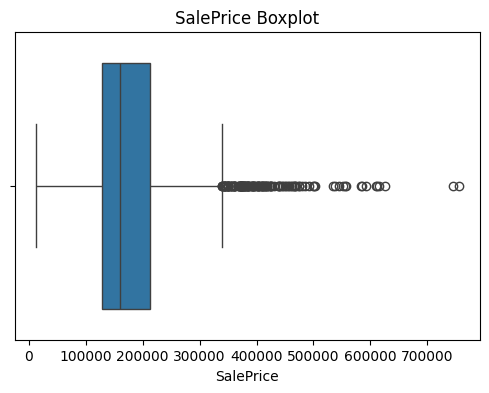

In [17]:
df = Spot_outliers(df)
plt.show()

Write a clean_data() function
-----------------------------------------------

---



In [18]:
def clean_data(df):
  df = df.copy()
  df = load_file(df)
  df = check_shape(df)
  df = data_type(df)
  df = missing_values(df)
  df = handle_missing(df)
  df = mask_full(df)
  df = Spot_outliers(df)

  assert df[["SalePrice", "Lot Frontage", "Garage Yr Blt"]].isnull().sum().sum() == 0
  assert (df["SalePrice"] > 0).all()
  assert df.shape[1] == expected_cols

  return df


In [19]:
def clean_data(df):
  df = df.copy()
  df = load_file(df)
  df = check_shape(df)
  df = data_type(df)
  df = missing_values(df)
  df = handle_missing(df)
  df = mask_full(df)
  df = Spot_outliers(df)


  assert df[["SalePrice", "Lot Frontage", "Garage Yr Blt"]].isnull().sum().sum() == 0
  assert (df["SalePrice"] > 0).all()
  assert df.shape[1] == cols_before - 4

  return df

Saving AmesHousing.csv to AmesHousing (1).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

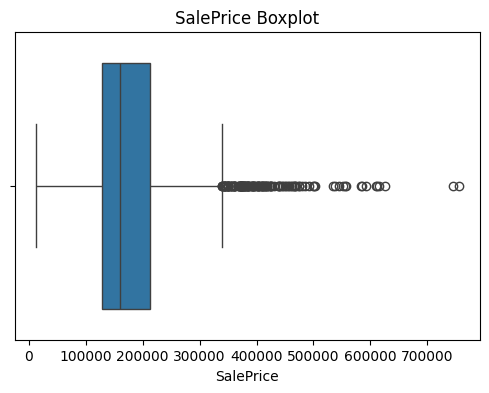

In [20]:
df_row = pd.read_csv("AmesHousing.csv")
cols_before = df_row.shape[1]

df_clean = clean_data(df_row)
